
# **1. Introduction**

This notebook contains the group work for the monthly car sales forecasting project. In this notebook, the dataset is explored and prepared before building forecasting models. The main purpose is to understand the behaviour of the data and create a common setup that all group members will use in their individual notebooks.

The dataset contains monthly car sales values over time. Since the data changes from month to month and shows repeating patterns, it is suitable for time series forecasting. The models used in this project are ARIMA, SARIMA and LSTM. Each model is implemented separately in different notebooks.

The work in this notebook includes loading the dataset, checking data quality, exploring trend and seasonality, analysing stationarity, defining the forecasting task and deciding the evaluation strategy.

GitHub Repository Link : https://github.com/RAJDONDA89/Group-project_-Advance-Forecasting.git

# **2. Importing Libraries**

The required Python libraries are imported for data handling, visualization and time series analysis.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import itertools

from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

# **3. Dataset Loading**

The dataset is imported from GitHub repo. The date column is converted into datetime format and set as the index so the data can be treated as a proper time series.

In [3]:
url = "https://raw.githubusercontent.com/RAJDONDA89/Group-project_-Advance-Forecasting/refs/heads/main/Data/monthly-car-sales.csv"

df = pd.read_csv(url)
df.columns = ["Date", "Sales"]
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)
df.head()


,Sales
Date,
1960-01-01,6550
1960-02-01,8728
1960-03-01,12026
1960-04-01,14395
1960-05-01,14587


# **4. Data Cleaning**



In [4]:
print("Shape:", df.shape)
print(df.head())
print(df.describe())
print("\nMissing values:\n", df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

print("\n")
df.info()

Shape: (108, 1)
            Sales
Date             
1960-01-01   6550
1960-02-01   8728
1960-03-01  12026
1960-04-01  14395
1960-05-01  14587
              Sales
count    108.000000
mean   14595.111111
std     4525.213913
min     5568.000000
25%    11391.250000
50%    14076.000000
75%    17595.750000
max    26099.000000

Missing values:
 Sales    0
dtype: int64
Duplicates: 0


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 108 entries, 1960-01-01 to 1968-12-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Sales   108 non-null    int64
dtypes: int64(1)
memory usage: 1.7 KB


The dataset is checked to understand its structure, data types and basic statistics. Missing values and duplicate records are also checked because these problems can affect forecasting performance.

After checking the dataset, no missing values or duplicate observations were found. This means the dataset is already clean and ready for analysis.

# **5. Exploratory Data Analysis**



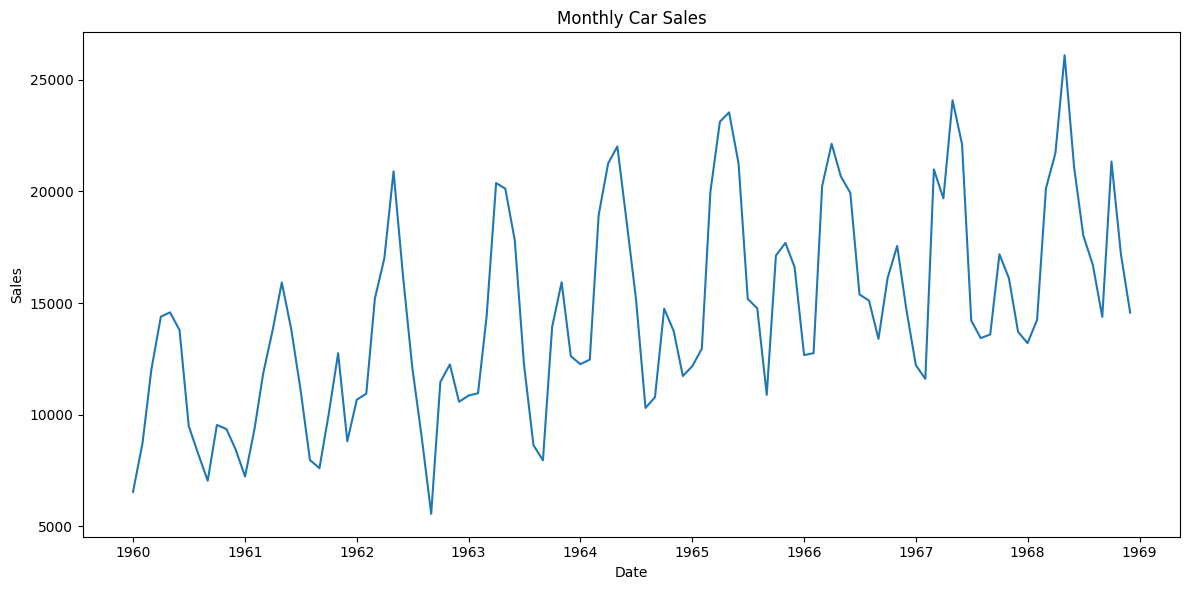

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["Sales"])
plt.title("Monthly Car Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

Exploratory data analysis is performed to better understand the behaviour of the monthly car sales data. The purpose is to identify trend, seasonality and fluctuations in the series before applying forecasting models.

The time series plot helps visualize how sales change over time. The graph shows that the sales values are not constant and there are repeating patterns across months.

## **5.1 Rolling statistics**

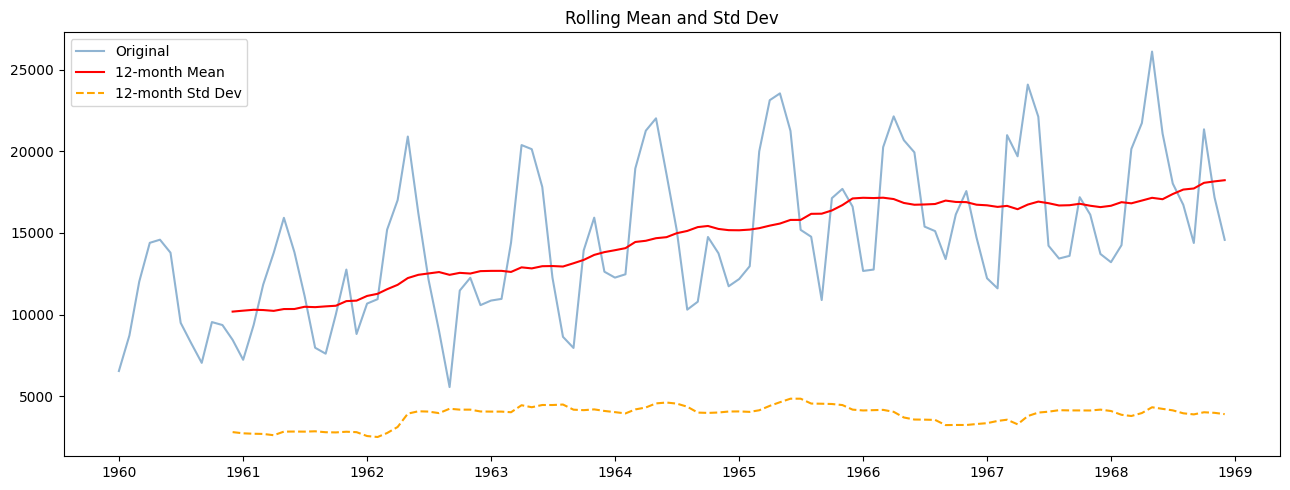

In [6]:
roll_mean = df["Sales"].rolling(window=12).mean()
roll_std  = df["Sales"].rolling(window=12).std()

plt.figure(figsize=(13, 5))
plt.plot(df["Sales"],  label="Original",          color="steelblue", alpha=0.6)
plt.plot(roll_mean,    label="12-month Mean",      color="red")
plt.plot(roll_std,     label="12-month Std Dev",   color="orange", linestyle="--")
plt.title("Rolling Mean and Std Dev")
plt.legend()
plt.tight_layout()
plt.show()

Rolling statistics are used to examine how the average level and variability of the data change over time. A 12-month rolling window is used because the dataset contains monthly observations and yearly patterns are expected.

The rolling mean changes over time, which suggests that the series is not stationary. This means differencing may be needed before applying ARIMA-type models.

## **5.2 Distribution**

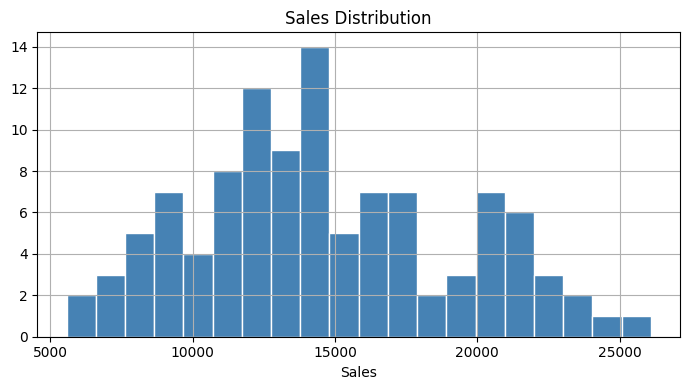

In [7]:
plt.figure(figsize=(7, 4))
df["Sales"].hist(bins=20, color="steelblue", edgecolor="white")
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.tight_layout()
plt.show()

The distribution plot is used to understand how the sales values are spread across the dataset. Most values are concentrated within a certain range, although some months show higher sales values.

This helps understand the overall behaviour of the dataset before modelling.

## **5.3 Year-over-Year Monthly Comparison**

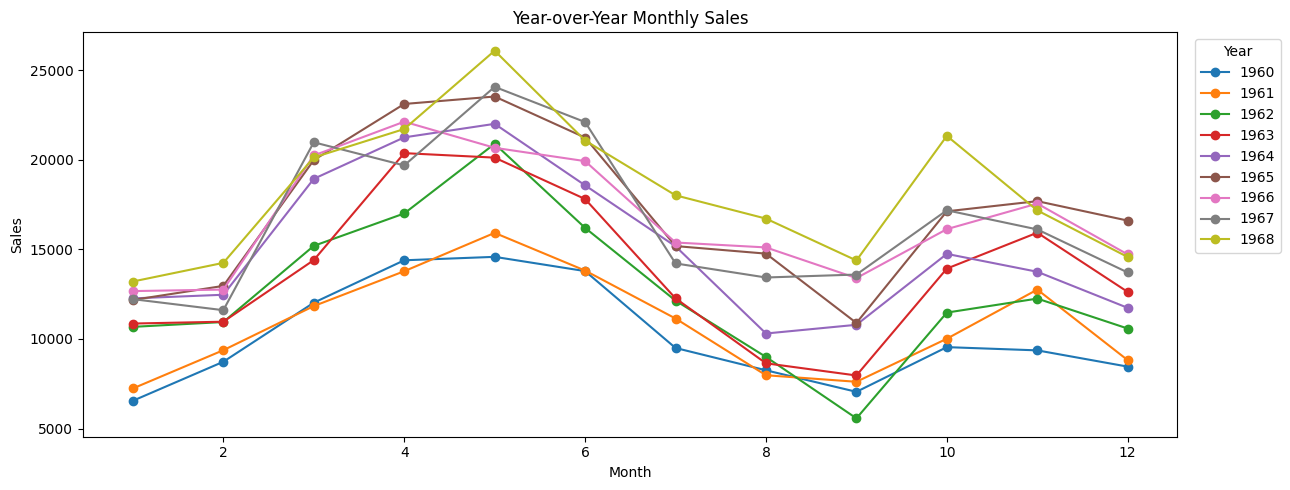

In [8]:
df["Year"]  = df.index.year
df["Month"] = df.index.month
yoy = df.pivot_table(index="Month", columns="Year", values="Sales")

plt.figure(figsize=(13, 5))
for year in yoy.columns:
    plt.plot(yoy.index, yoy[year], marker="o", label=str(year))
plt.title("Year-over-Year Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend(title="Year", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

df.drop(columns=["Year", "Month"], inplace=True)

The year-over-year comparison plot shows how monthly sales behave across different years. Similar patterns can be seen repeating in several years, which suggests that the dataset contains seasonality.

This is important because seasonal models such as SARIMA are designed to capture repeating seasonal patterns.

## **5.4 Seasonal Decomposition**

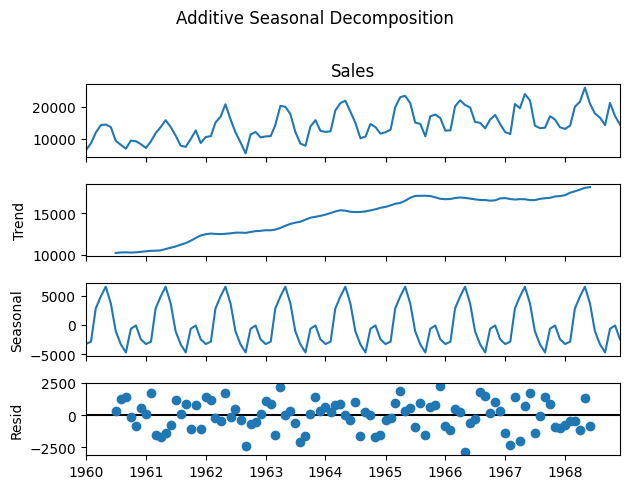

In [9]:
decomposition = seasonal_decompose(df["Sales"], model="additive", period=12)
decomposition.plot()
plt.suptitle("Additive Seasonal Decomposition", y=1.01)
plt.tight_layout()
plt.show()


Seasonal decomposition separates the time series into trend, seasonal and residual components. This helps understand which part of the data comes from long-term movement and which part comes from repeating seasonal behaviour.

The decomposition graph shows that the dataset contains a clear seasonal component. Because of this, seasonal forecasting models may perform better than simple non-seasonal models.

# **6. Stationarity and Correlation Analysis**

## **6.1 ACF and PACF Original series**

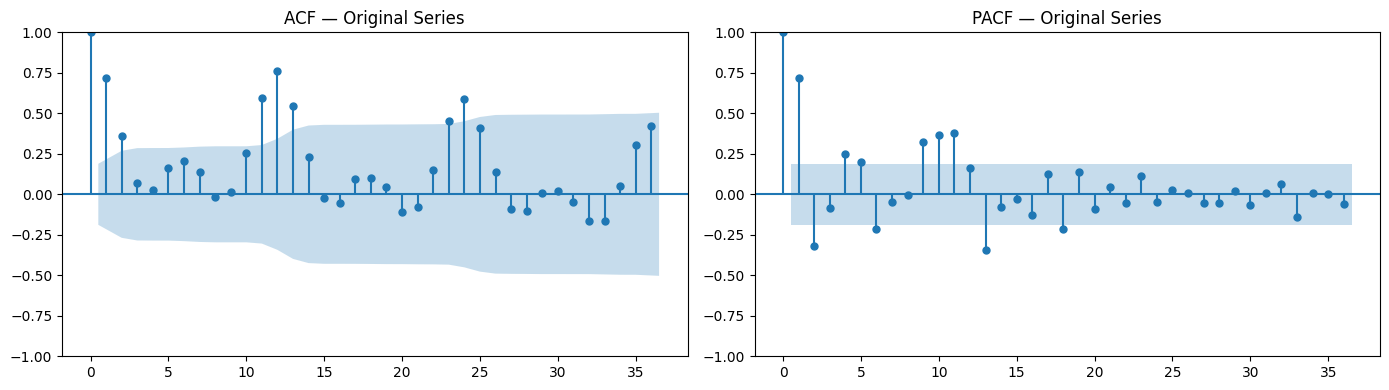

In [10]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf( df["Sales"], lags=36, ax=axes[0], title="ACF — Original Series")
plot_pacf(df["Sales"], lags=36, ax=axes[1], title="PACF — Original Series")
plt.tight_layout()
plt.show()

The autocorrelation function and partial autocorrelation function are used to study the relationship between current values and past observations.

The plots of the original series show strong autocorrelation, which means the current sales values are related to previous months.

## **6.2 ADF Test**



In [11]:
adf_result = adfuller(df["Sales"])

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -1.2238127661752858
p-value: 0.6632691049832861
Critical Values:
1%: -3.5011373281819504
5%: -2.8924800524857854
10%: -2.5832749307479226


Stationarity is important in time series forecasting because many forecasting models assume that the data remains stable over time.

The Augmented Dickey-Fuller test is used to check whether the original sales series is stationary. The result suggests that the original series is non-stationary, so differencing is needed before modelling.

## **6.3 First Differencing**

ADF Test: Original Series
ADF Statistic: -1.2238127661752858
p-value: 0.6632691049832861
Critical Value (1%): -3.5011373281819504
Critical Value (5%): -2.8924800524857854
Critical Value (10%): -2.5832749307479226
Result: The series is non-stationary.
ADF Test: First-Differenced Series
ADF Statistic: -6.1997992308006955
p-value: 5.8447525992768446e-08
Critical Value (1%): -3.5011373281819504
Critical Value (5%): -2.8924800524857854
Critical Value (10%): -2.5832749307479226
Result: The series is stationary.


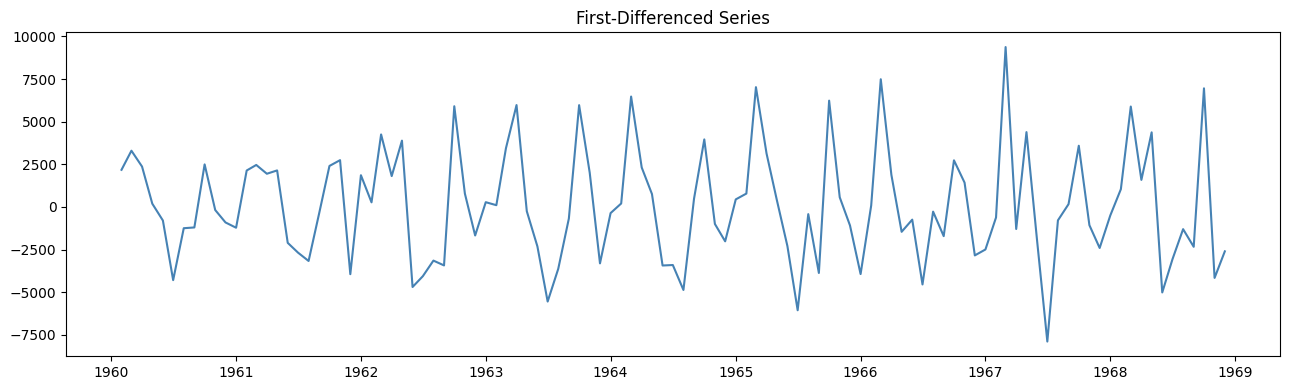

In [19]:
def adf_test(series, label=''):
    result = adfuller(series.dropna())

    print(f'ADF Test: {label}')
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])

    for key, value in result[4].items():
        print(f'Critical Value ({key}): {value}')

    if result[1] <= 0.05:
        print("Result: The series is stationary.")
    else:
        print("Result: The series is non-stationary.")

adf_test(df["Sales"], label="Original Series")

# First difference
sales_diff = df["Sales"].diff().dropna()
adf_test(sales_diff, label="First-Differenced Series")
plt.figure(figsize=(13, 4))
plt.plot(sales_diff, color="steelblue")
plt.title("First-Differenced Series")
plt.tight_layout()
plt.show()

First differencing is applied to remove trend and make the series more stable. After differencing, the changes between consecutive months are analysed instead of the original values.

The differenced series appears more stable than the original series, which makes it more suitable for ARIMA-type models.

## **6.4 ACF and PACF of the Differenced Series**

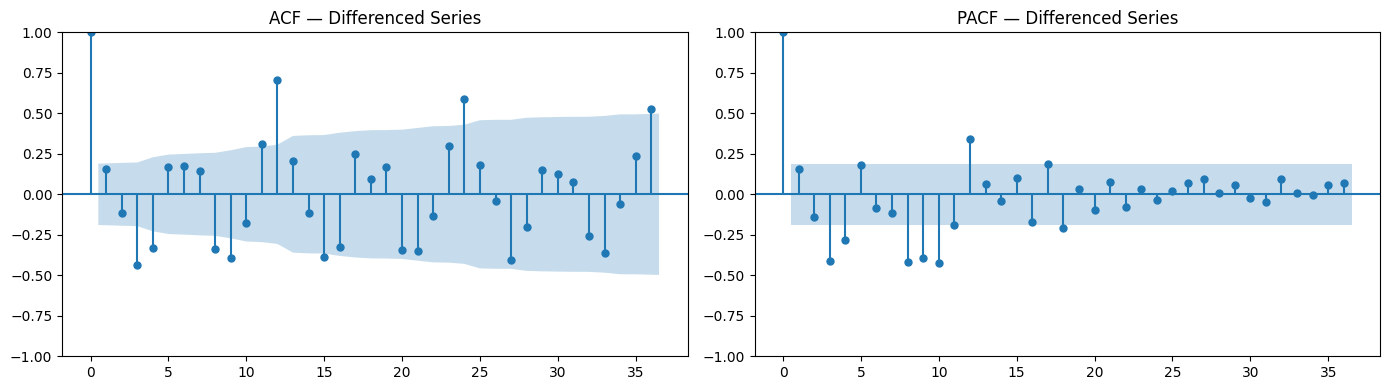

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf( sales_diff, lags=36, ax=axes[0], title="ACF — Differenced Series")
plot_pacf(sales_diff, lags=36, ax=axes[1], title="PACF — Differenced Series")
plt.tight_layout()
plt.show()

The ACF and PACF plots are created again after differencing. These plots help identify possible autoregressive and moving-average behaviour in the data.

The differenced plots are more useful for selecting ARIMA and SARIMA parameters because the series becomes closer to stationary after differencing.

# **7. Forecasting Problem Definition**

The goal of this project is to forecast monthly car sales for the final 12 months of the dataset.

The target variable is monthly car sales, and the forecasting horizon is 12 months. The models compared in this project are ARIMA, SARIMA and LSTM.

Each model will use the same train-test split and evaluation metrics so that the comparison is fair.

# **8. Train-Test Split**

In [21]:
train = df[:-12]
test = df[-12:]

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (96, 1)
Test shape: (12, 1)


The final 12 observations are used as the test set, while the earlier observations are used as the training set.

This approach simulates a real forecasting situation where future values are unknown and predictions must be made using only past observations.

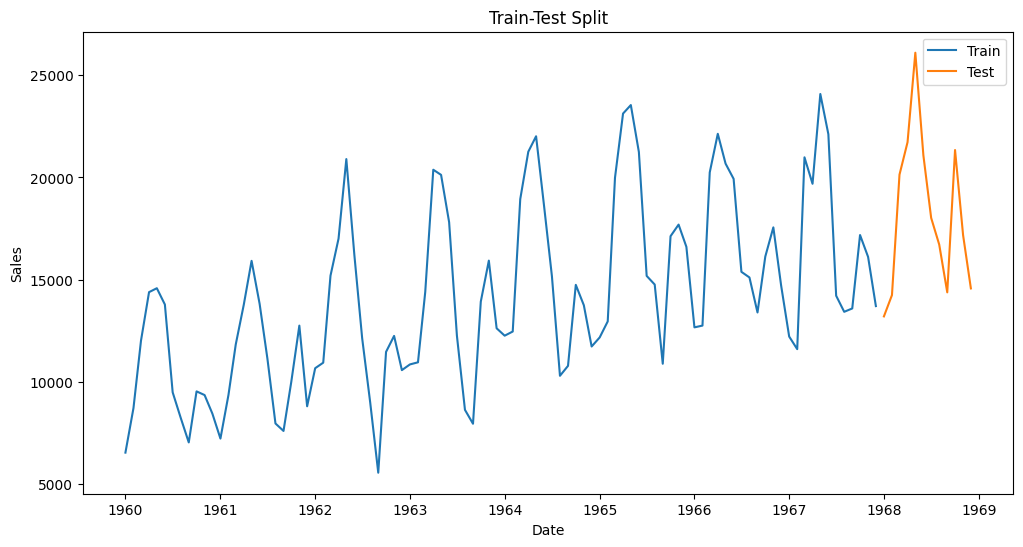

In [22]:
plt.figure(figsize=(12, 6))
plt.plot(train.index, train["Sales"], label="Train")
plt.plot(test.index, test["Sales"], label="Test")
plt.title("Train-Test Split")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

# **9. Validation Strategy**

A hold-out validation strategy is used in this project. The model is trained using historical observations and evaluated on the final 12 months.

Using the same validation setup across all notebooks allows the models to be compared fairly.

# **10. Evaluation Metrics**

The models are evaluated using Mean Absolute Error and Root Mean Squared Error.

Mean Absolute Error measures the average size of forecasting errors, while Root Mean Squared Error gives more importance to larger mistakes.

Using both metrics helps provide a balanced evaluation of forecasting performance.

# **11. Group Model Allocation**

Each group member is responsible for implementing one forecasting model and one baseline method in a separate notebook.

The project compares classical forecasting methods such as ARIMA and SARIMA with an advanced deep learning model, LSTM.

This allows the group to compare different forecasting approaches on the same dataset.

# **12. Conclusion**

The exploratory analysis shows that the monthly car sales dataset contains trend and seasonal behaviour. The original series is non-stationary, but differencing helps make the data more stable for forecasting.

The seasonal decomposition and year-over-year comparison both suggest that seasonality is an important feature of the dataset. This supports the use of seasonal forecasting models such as SARIMA.

The shared setup created in this notebook will now be used in the individual modelling notebooks for ARIMA, SARIMA and LSTM.